# Feladatleírás – Diabetes dataset

A feladat a scikit-learn beépített Diabetes datasetjén alapul. Az adathalmaz orvosi jellegű mérési adatokat tartalmaz, amelyek különböző páciensek egészségi állapotát írják le.

A bemeneti változók különböző klinikai és fizikai jellemzők, például életkor, nem, testtömegindex, vérnyomás, valamint több vérkémiai mérés. Ezek a változók szolgálnak a modell bemeneteként.

A célváltozó egy folytonos érték, amely a cukorbetegség előrehaladásának mértékét jelzi egy éves időtávon belül. Az adathalmaz eredetileg regressziós problémák vizsgálatára készült, de a célváltozó átalakításával osztályozási feladatként is feldolgozható.

In [1]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
data = load_diabetes()
X = data.data
y_reg = data.target

In [3]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
reg_model = RandomForestRegressor(random_state=42)
reg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_model.predict(X_test_reg)

In [4]:
threshold = y_reg.mean()
y_clf = (y_reg > threshold).astype(int)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_clf, y_train_clf)
y_pred_clf = clf_model.predict(X_test_clf)

## 1. feladat - MAE

Számítsd ki a modell predikcióira a Mean Absolute Error (MAE) értékét a teszthalmazon. Értelmezd, hogy ez az érték átlagosan mekkora abszolút hibát jelent a modell előrejelzéseiben.

In [5]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_reg, y_pred_reg)
print("MAE:", mae)

MAE: 44.053033707865175


## 2. feladat – MSE

Számítsd ki a Mean Squared Error (MSE) értékét a teszthalmazon. Vizsgáld meg, hogyan bünteti ez a metrika a nagyobb hibákat, és hasonlítsd össze a MAE-val.

In [6]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test_reg, y_pred_reg)
print("MSE:", mse)

MSE: 2952.0105887640448


## 3. feladat – RMSE

Számítsd ki a Root Mean Squared Error (RMSE) értékét. Értelmezd, hogy ez hogyan viszonyul az eredeti célváltozó skálájához, és miért könnyebb értelmezni, mint az MSE-t.

In [7]:
import numpy as np

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 54.332408273184846


## 4. feladat – R² score

Számítsd ki az R² score-t a modellre. Vizsgáld meg, hogy a modell mennyire jól magyarázza a célváltozó varianciáját, és értelmezd az eredményt 0 és 1 között.

In [8]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_reg, y_pred_reg)
print("R2:", r2)

R2: 0.4428225673999313


## 5. feladat – Accuracy

Számítsd ki az accuracy értékét a teszthalmazon. Értelmezd, hogy az összes előrejelzés közül hány volt helyes, és hogy ez mennyire megbízható metrika lehet egy esetleges osztályegyensúly-probléma esetén.

In [9]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test_clf, y_pred_clf)
print("Accuracy:", acc)

Accuracy: 0.7640449438202247


## 6. feladat – Precision és Recall

Számítsd ki a precision és recall értékeket. Értelmezd a kettő közötti különbséget, és vizsgáld meg, hogy a modell inkább a hamis pozitív vagy a hamis negatív hibákat követi el gyakrabban.

In [10]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.95
Recall: 0.48717948717948717


## 7. feladat – F1-score és Confusion Matrix

Számítsd ki az F1-score-t, valamint készíts konfúziós mátrixot. Értelmezd, hogy mennyire kiegyensúlyozott a modell teljesítménye a két osztály között, és hogyan tükrözi ezt az F1-score.

F1-score: 0.6440677966101694


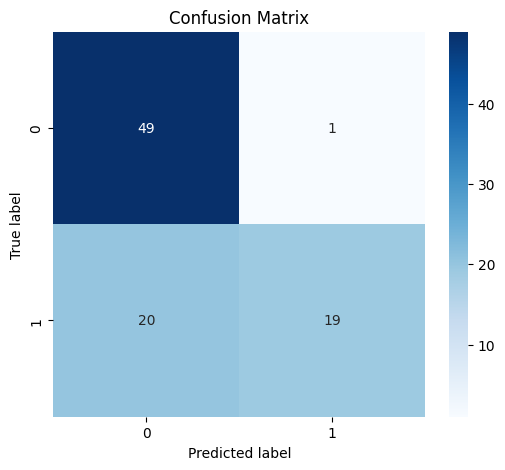

In [11]:
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

f1 = f1_score(y_test_clf, y_pred_clf)
cm = confusion_matrix(y_test_clf, y_pred_clf)

print("F1-score:", f1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()